# **Taller 3: Segmentación**

## **IMÁGENES Y VISIÓN - ISIS4825**

### **Profesor**: PhD Juan Pablo Reyes

### **Autores**: Estefanía Laverde, Harvy Benitez.

**Nota:** Se declara el uso de ChatGPT en la elaboración de la versión final de este Taller. Siguiendo la recomendación del profesor, se utilizó como base el código provisto en el enlace del Taller 3, dado que este facilita implementaciones específicas que resultan innecesariamente complejas cuando se generan desde cero con una herramienta de IA.

La IA generativa fue empleada principalmente para mejorar la redacción de los párrafos de algunas respuestas, pero haciendo el análisis por cuenta propia.

In [47]:
!pip3 install scikit-image --quiet


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [2]:
from skimage.util import random_noise
from skimage.filters import threshold_local
from skimage.segmentation import flood
from skimage.segmentation import slic
from skimage import segmentation

from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
import numpy as np
import cv2
import os

# **1. Segmentación por umbralización**

### **1.1 Cree una nueva sección en su notebook**
### **1.2 Cargue la imagen de trabajo objects.png  y visualícela**

In [3]:
# guardar el path de las imagenes
images_path = 'images/'

# observamos las imagenes en el directorio
os.listdir(images_path)

['CHEST_MASK.png',
 'AMOUR.png',
 'CHEST.png',
 'AMOUR_AVEC_RAMPE.png',
 'OBJECTS.png',
 'BABOON.png',
 'TEXT.png']

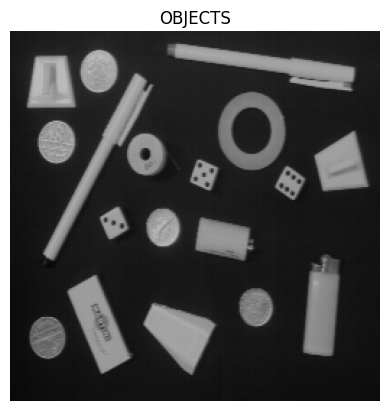

In [50]:
# lectura de la imagen
objects_image = cv2.imread(images_path + 'OBJECTS.png', cv2.IMREAD_GRAYSCALE)

# visualizar la imagen
plt.imshow(objects_image, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.title('OBJECTS')
plt.show()


### **1.3 Visualice el histograma de la imagen de trabajo**

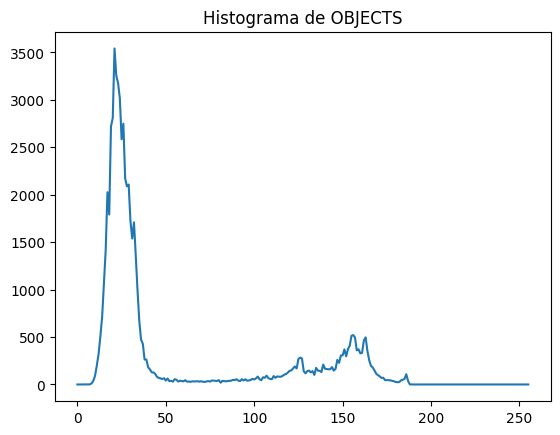

In [51]:
objects_hist = cv2.calcHist([objects_image], [0], None, [256], [0, 256])

plt.plot(objects_hist)
plt.title('Histograma de OBJECTS')
plt.show()

### **1.4 Aplique el algoritmo de umbralización global**

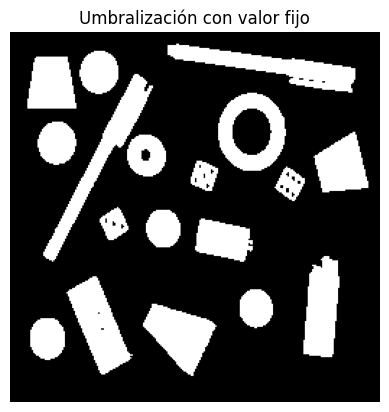

In [52]:
_, thres_image = cv2.threshold(objects_image, 65, 255, cv2.THRESH_BINARY)

plt.imshow(thres_image, cmap='gray')
plt.axis('off')
plt.title('Umbralización con valor fijo')
plt.show()

### **1.5 Aplique el algoritmo de umbralización de Otsu con un solo valor**

Valor de umbral para Otsu: 84.0


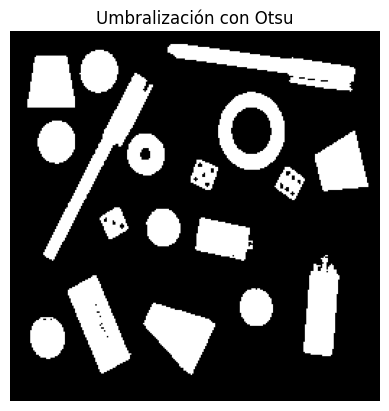

In [53]:
threshold, thres_image_otsu = cv2.threshold(objects_image, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
print(f"Valor de umbral para Otsu: {threshold}")

plt.imshow(thres_image_otsu, cmap='gray')
plt.axis('off')
plt.title('Umbralización con Otsu')
plt.show()

### **1.6 Ahora introduzca ruido gaussiano aditivo con varianza de 0.001 y luego con varianza de 0.05. Visualice el histograma de la imagen resultante. ¿Qué sucede? ¿Por qué sucede esto?**

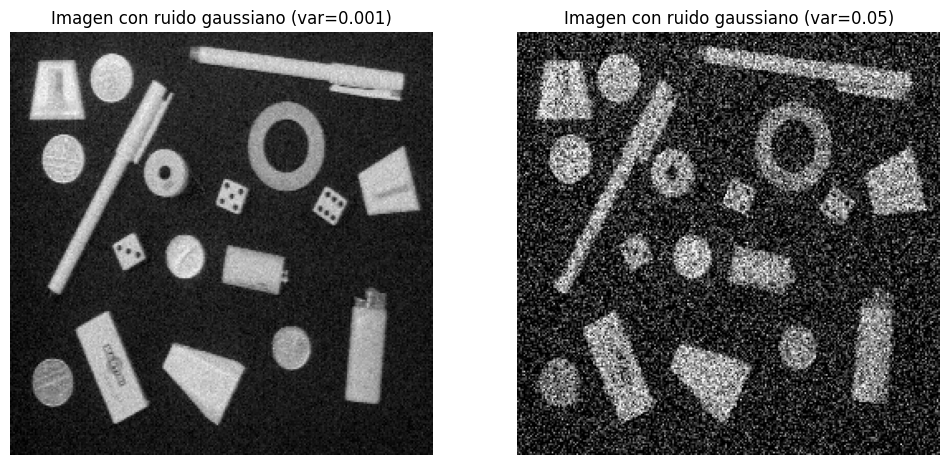

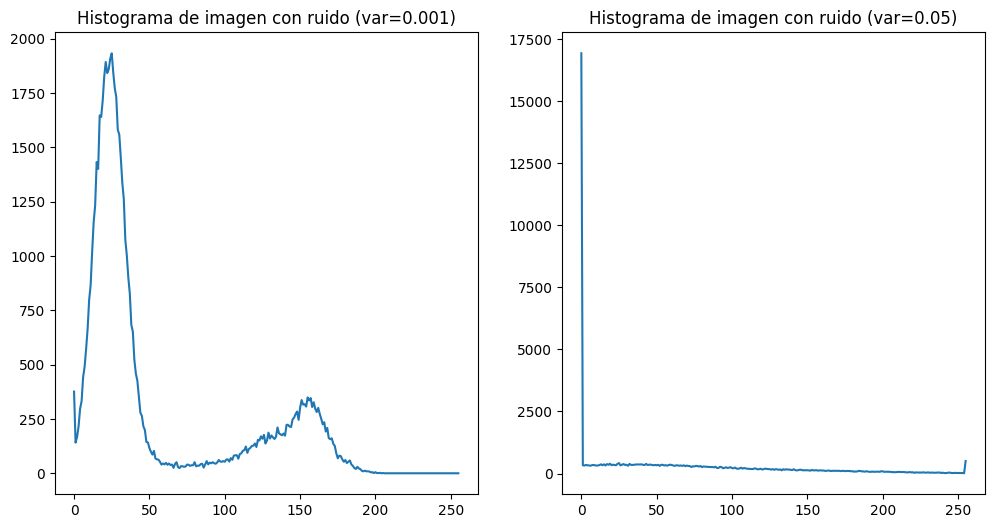

In [54]:
# introducir ruido gausiando 
noised_image_001 = random_noise(objects_image, mode='gaussian', mean=0,  var=0.001)
noised_image_05 = random_noise(objects_image, mode='gaussian', mean=0,  var=0.05)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(noised_image_001, cmap='gray')
plt.axis('off')
plt.title('Imagen con ruido gaussiano (var=0.001)')

plt.subplot(1, 2, 2)
plt.imshow(noised_image_05, cmap='gray')
plt.axis('off')
plt.title('Imagen con ruido gaussiano (var=0.05)')
plt.show()

# histogramas de las imágenes ruidosas

# convertir las imagenes ruidosas a 8 bits - la imagen original es continua de 0 a 1. Se multiplica por 255 y luego se pasa a 8bits
noised_001_uint8 = (noised_image_001 * 255).astype(np.uint8)
noised_05_uint8 = (noised_image_05 * 255).astype(np.uint8)

objects_hist_001 = cv2.calcHist([noised_001_uint8], [0], None, [256], [0, 256])
objects_hist_05 = cv2.calcHist([noised_05_uint8], [0], None, [256], [0, 256])

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(objects_hist_001)
plt.title('Histograma de imagen con ruido (var=0.001)')

plt.subplot(1, 2, 2)
plt.plot(objects_hist_05)
plt.title('Histograma de imagen con ruido (var=0.05)')
plt.show()


Al introducir ruido gaussiano aditivo a la imagen, el valor de cada píxel se modifica mediante la suma de una variable aleatoria extraída de una distribución normal con media $\mu = 0$ y varianza $\sigma^2$ definida. En estas imágenes se percibe que al aumentar la varianza, el ruido aleatorio se aleja de la media tomando valores más extremos, lo que genera que la gran mayoría de ellos se saturen a los valores máximos y mínimos de la imagen, es decir, 0 y 255. 

En el histograma se ven reflejados estos efectos: la varianza de 0.001 mantiene el ruido cercano a la media (0), por lo que, la distribución de la imagen resultante es muy similar a la original, mientras que, la varianza de 0.05 genera una gran cantidad de valores saturados, dando como resultado dos picos principales, el mayor en torno a 0 y el otro en torno a 255.

### **1.7 Vuelva a correr las umbralizaciones sobre la imagen ¿Cómo afecta el ruido al resultado?**

Valor de umbral para Otsu (var=0.001): 84.0
Valor de umbral para Otsu (var=0.05): 85.0


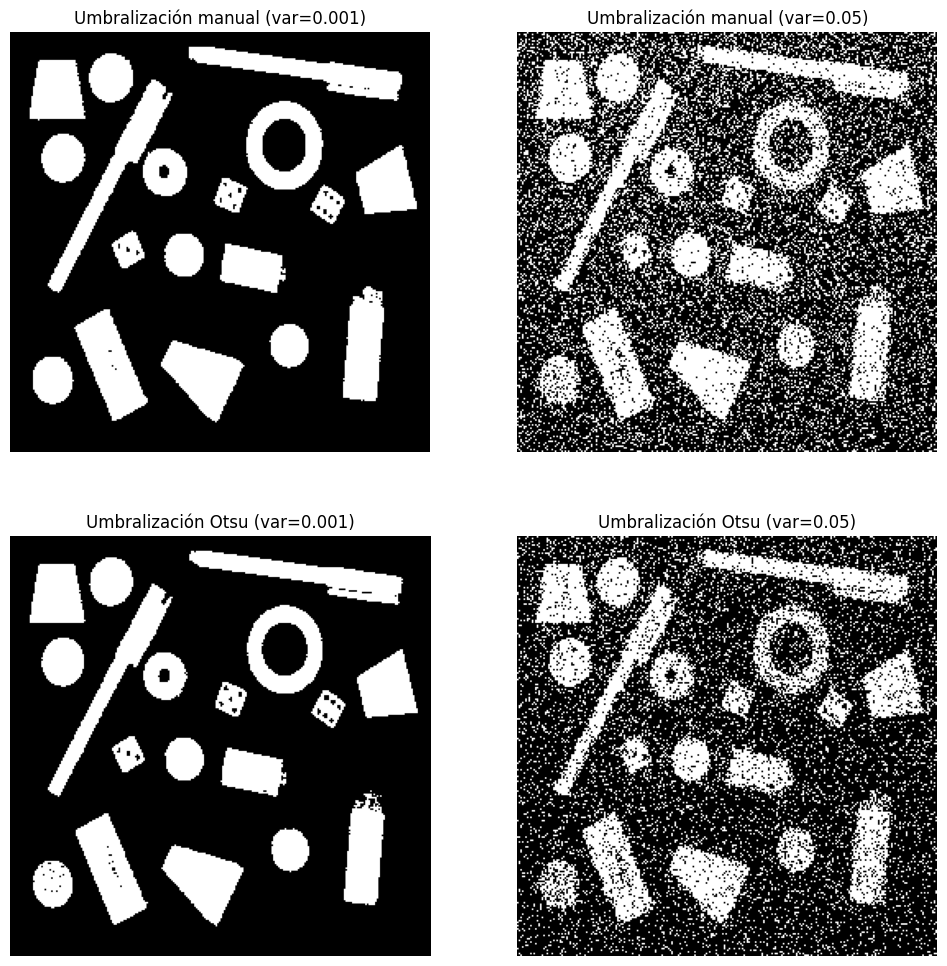

In [55]:
# umbralizaciones manuales con valor 65
_, thres_image_001 = cv2.threshold(noised_001_uint8, 65, 255, cv2.THRESH_BINARY)
_, thres_image_05 = cv2.threshold(noised_05_uint8, 65, 255, cv2.THRESH_BINARY)

# umbralizaciones con Otsu
threshold_001, thres_image_otsu_001 = cv2.threshold(noised_001_uint8, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
threshold_05, thres_image_otsu_05 = cv2.threshold(noised_05_uint8, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
print(f"Valor de umbral para Otsu (var=0.001): {threshold_001}")
print(f"Valor de umbral para Otsu (var=0.05): {threshold_05}")

# visualización de las imagenes resultantes

plt.figure(figsize=(12, 12))
plt.subplot(2, 2, 1)
plt.imshow(thres_image_001, cmap='gray')
plt.axis('off')
plt.title('Umbralización manual (var=0.001)')
plt.subplot(2, 2, 2)
plt.imshow(thres_image_05, cmap='gray')
plt.axis('off')
plt.title('Umbralización manual (var=0.05)')
plt.subplot(2, 2, 3)
plt.imshow(thres_image_otsu_001, cmap='gray')
plt.axis('off')
plt.title('Umbralización Otsu (var=0.001)')
plt.subplot(2, 2, 4)
plt.imshow(thres_image_otsu_05, cmap='gray')
plt.axis('off')
plt.title('Umbralización Otsu (var=0.05)')
plt.show()  



El ruido gaussiano aditivo degrada la eficacia de la umbralización a medida que aumenta la varianza. Con una varianza baja, el histograma de la imagen continúa siendo bimodal, de modo que tanto con el umbral manual como con aquel del método Otsu se logre una segmentación adecuada. Sin embargo, al incrementar la varianza a 0.05 el ruido genera una gran cantidad de valores saturados, lo que distorsiona el histograma creando nuevos picos en valores extremos y, vuelve más difícil encontrar un umbral que separe de forma clara los objetos del fondo. Como resultado, en la imagen segmentada aparece mucho ruido, similar al efecto de sal y pimienta, lo que demuestra que el algoritmo no pudo adaptarse a la nueva distribución de la imagen.

### **1.8 Cargue ahora la imagen de trabajo de text, visualícela y visualice su histograma**

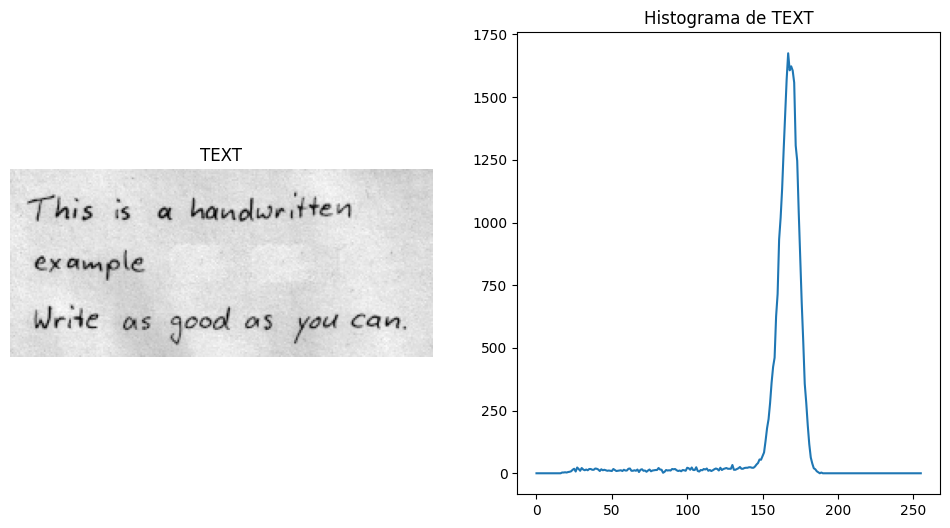

In [56]:
text_image = cv2.imread(images_path + 'TEXT.png', cv2.IMREAD_GRAYSCALE)
hist_text = cv2.calcHist([text_image], [0], None, [256], [0, 256])

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(text_image, cmap='gray')
plt.axis('off')
plt.title('TEXT')
plt.subplot(1, 2, 2)
plt.plot(hist_text)
plt.title('Histograma de TEXT')
plt.show()

### **1.9 Introduzca ahora una sombra circular lateral y una sombra sinusoidal en la imagen (pruebe con diferentes valores y úselos para los pasos 10 y 11). Visualice el resultado.**

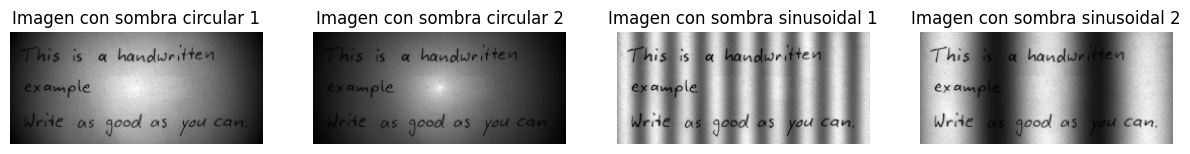

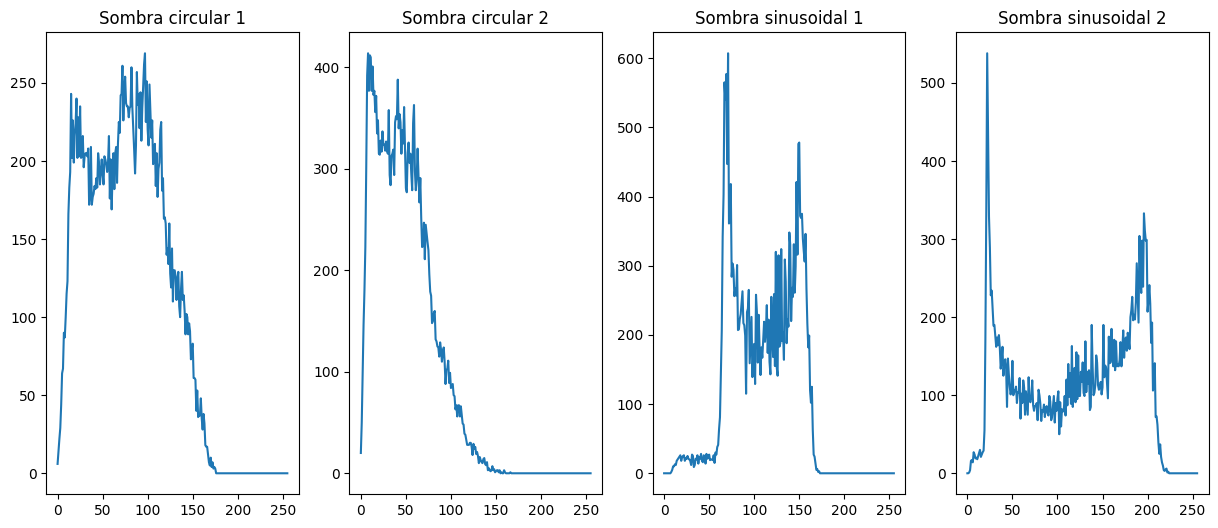

In [57]:
# calculo de la sobra circular 1
rows, cols = text_image.shape
x, y = np.meshgrid(np.arange(cols), np.arange(rows))
cx, cy = cols // 2, rows // 2  # centro de la imagen
distance = np.sqrt((x - cx) ** 2 + (y - cy) ** 2) # distancia de cada píxel al centro
max_dist = np.sqrt(cx**2 + cy**2) # distancia máxima posible (esquina de la imagen)
spot_shading = 1 - (distance / max_dist)  # aplicar un gradiente
spot_image = text_image * spot_shading
spot_image = spot_image.astype(np.uint8)

# calculo de la sobra circular 2
rows, cols = text_image.shape
x, y = np.meshgrid(np.arange(cols), np.arange(rows))
cx, cy = cols // 2, rows // 2  # centro de la imagen
distance = np.sqrt((x - cx) ** 2 + (y - cy) ** 2) # distancia de cada píxel al centro
max_dist = np.sqrt(cx**2 + cy**2) # distancia máxima posible (esquina de la imagen)
spot_shading = 1 - (distance / max_dist)**0.5  # aplicar un gradiente
spot_image2 = text_image * spot_shading
spot_image2 = spot_image2.astype(np.uint8)

# calculo de sombra sinusoidal 1
frequency = 30  # cantidad de perturbaciones
amplitude = 0.4  # intensidad de los picos
sinusoidal_shading = (1 + amplitude * np.sin(2 * np.pi * x / frequency)) / 1.5 # aplicar
sinusoidal_image = text_image * sinusoidal_shading
sinusoidal_image = sinusoidal_image.astype(np.uint8)

# calculo de sombra sinusoidal 2
frequency = 100  # cantidad de perturbaciones
amplitude = 0.8  # intensidad de los picos
sinusoidal_shading2 = (1 + amplitude * np.sin(2 * np.pi * x / frequency)) / 1.5 # aplicar
sinusoidal_image2 = text_image * sinusoidal_shading2
sinusoidal_image2 = sinusoidal_image2.astype(np.uint8)

# visualización de las imágenes con sombras
plt.figure(figsize=(15, 6))
plt.subplot(1, 4, 1)
plt.imshow(spot_image, cmap='gray')
plt.axis('off')
plt.title('Imagen con sombra circular 1')
plt.subplot(1, 4, 2)
plt.imshow(spot_image2, cmap='gray')
plt.axis('off')
plt.title('Imagen con sombra circular 2')

plt.subplot(1, 4, 3)
plt.imshow(sinusoidal_image, cmap='gray')
plt.axis('off')
plt.title('Imagen con sombra sinusoidal 1')
plt.subplot(1, 4, 4)
plt.imshow(sinusoidal_image2, cmap='gray')
plt.axis('off')
plt.title('Imagen con sombra sinusoidal 2')
plt.show()

# visualización de los histogramas de las imágenes con sombras
hist_spot1 = cv2.calcHist([spot_image], [0], None, [256], [0, 256])
hist_spot2 = cv2.calcHist([spot_image2], [0], None, [256], [0, 256])

hist_sinusoidal1 = cv2.calcHist([sinusoidal_image], [0], None, [256], [0, 256])
hist_sinusoidal2 = cv2.calcHist([sinusoidal_image2], [0], None, [256], [0, 256])

plt.figure(figsize=(15, 6))
plt.subplot(1, 4, 1)
plt.plot(hist_spot1)
plt.title('Sombra circular 1')
plt.subplot(1, 4, 2)
plt.plot(hist_spot2)
plt.title('Sombra circular 2')
plt.subplot(1, 4, 3)
plt.plot(hist_sinusoidal1)
plt.title('Sombra sinusoidal 1')
plt.subplot(1, 4, 4)
plt.plot(hist_sinusoidal2)
plt.title('Sombra sinusoidal 2')
plt.show()

### **1.10 Aplique el algoritmo de umbralización de Otsu sobre la imagen original y las dos modificaciones. ¿Qué sucede? ¿Por qué sucede esto? ¿Qué alternativas puede emplear para mitigar este resultado?**

Valor de umbral para sombra circular 1: 75.0
Valor de umbral para sombra circular 2: 51.0
Valor de umbral para sombra sinusoidal 1: 108.0
Valor de umbral para sombra sinusoidal 2: 109.0


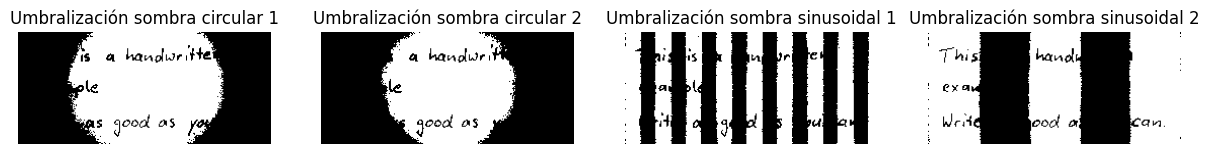

In [58]:
# umbralizaciones manuales con valor 65
thresh1, thres_image_spot = cv2.threshold(spot_image, 65, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
thresh2, thres_image_spot2 = cv2.threshold(spot_image2, 65, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
thresh3, thres_image_sinusoidal1 = cv2.threshold(sinusoidal_image, 65, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
thresh4, thres_image_sinusoidal2 = cv2.threshold(sinusoidal_image2, 65, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)

print(f"Valor de umbral para sombra circular 1: {thresh1}")
print(f"Valor de umbral para sombra circular 2: {thresh2}")
print(f"Valor de umbral para sombra sinusoidal 1: {thresh3}")
print(f"Valor de umbral para sombra sinusoidal 2: {thresh4}")

# visualización
plt.figure(figsize=(15, 6))
plt.subplot(1, 4, 1)
plt.imshow(thres_image_spot, cmap='gray')
plt.axis('off')
plt.title('Umbralización sombra circular 1')
plt.subplot(1, 4, 2)
plt.imshow(thres_image_spot2, cmap='gray')
plt.axis('off')
plt.title('Umbralización sombra circular 2')
plt.subplot(1, 4, 3)
plt.imshow(thres_image_sinusoidal1, cmap='gray')
plt.axis('off')
plt.title('Umbralización sombra sinusoidal 1')
plt.subplot(1, 4, 4)
plt.imshow(thres_image_sinusoidal2, cmap='gray')
plt.axis('off')
plt.title('Umbralización sombra sinusoidal 2')
plt.show()

La introducción de variaciones de iluminación como sombras de diversas naturalezas altera la distribución de intensidades en el histograma, eliminando la separación clara entre las clases, en este caso texto y fondo. Esto genera un solapamiento en el espectro de gris, donde los píxeles de la sombra adquieren valores de intensidad similares a los del texto. Como el algoritmo de Otsu busca un umbral global que minimice la varianza intra-clase, termina seleccionando un valor que clasifica erróneamente las sombras como parte del texto en las 4 imágenes.

Para mitigar este efecto, se puede realizar una umbralización adaptativa, que calcule umbrales locales para cada región, de modo que las diferencias de tonalidad causadas por la sombra no afecten globalmente la segmentación. Otras alternativas que se pueden emplear son técnicas de preprocesamiento como filtro de reducción de ruido o segmentación por contornos, que pueden ayudar a separar el texto.

### **1.11 Aplique ahora un algoritmo de adaptación del umbral en función de las propiedades locales. Compare sus resultados con el algoritmo anterior, usando varios valores para el vecindario local. ¿En qué cambia el resultado con relación al método de Otsu? ¿Qué implicaciones tiene esto? ¿Cómo puede mejorar el resultado de la segmentación para reducir el ruido en ambos casos?**

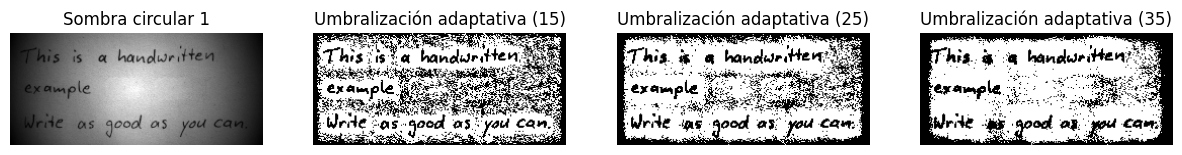

In [59]:
# aplicar umbralización adaptativa - spot 1
vecindarios = [15, 25, 35] 

umbralizaciones = []
for v in vecindarios:
    ti = threshold_local(spot_image, block_size=v, method='mean') #NOTA: X debe ser impar
    binary_image = spot_image > ti
    thresholded_image = binary_image*255
    umbralizaciones.append(thresholded_image)


plt.figure(figsize=(15, 6))
plt.subplot(1, 4, 1)
plt.imshow(spot_image, cmap='gray')
plt.axis('off')
plt.title('Sombra circular 1')
for i, v in enumerate(vecindarios):
    plt.subplot(1, 4, i+2)
    plt.imshow(umbralizaciones[i], cmap='gray')
    plt.axis('off')
    plt.title(f'Umbralización adaptativa ({v})')
plt.show()


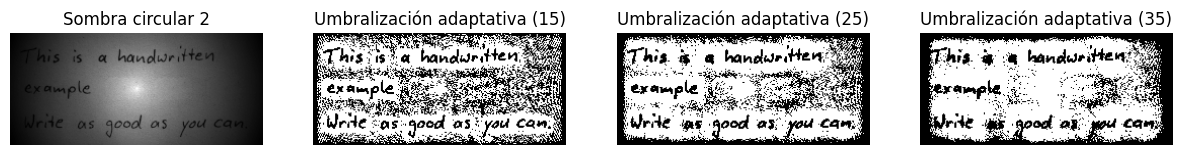

In [60]:
# aplicar umbralización adaptativa - spot 1
vecindarios = [15, 25, 35] 

umbralizaciones = []
for v in vecindarios:
    ti = threshold_local(spot_image2, block_size=v, method='mean') #NOTA: X debe ser impar
    binary_image = spot_image2 > ti
    thresholded_image = binary_image*255
    umbralizaciones.append(thresholded_image)


plt.figure(figsize=(15, 6))
plt.subplot(1, 4, 1)
plt.imshow(spot_image2, cmap='gray')
plt.axis('off')
plt.title('Sombra circular 2')
for i, v in enumerate(vecindarios):
    plt.subplot(1, 4, i+2)
    plt.imshow(umbralizaciones[i], cmap='gray')
    plt.axis('off')
    plt.title(f'Umbralización adaptativa ({v})')
plt.show()


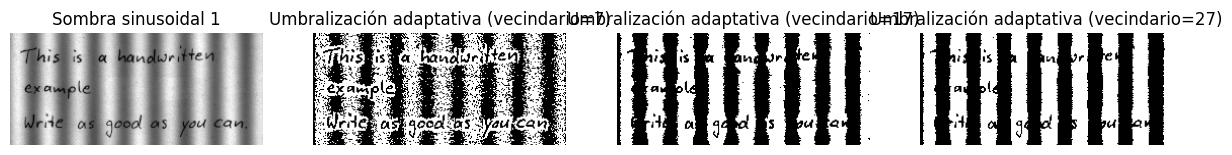

In [61]:
vecindarios = [7, 17, 27]

umbralizaciones = []
for v in vecindarios:
    ti = threshold_local(sinusoidal_image, block_size=v, method='mean') #NOTA: X debe ser impar
    binary_image = sinusoidal_image > ti
    thresholded_image = binary_image*255
    umbralizaciones.append(thresholded_image)


plt.figure(figsize=(15, 6))
plt.subplot(1, 4, 1)
plt.imshow(sinusoidal_image, cmap='gray')
plt.axis('off')
plt.title('Sombra sinusoidal 1')
for i, v in enumerate(vecindarios):
    plt.subplot(1, 4, i+2)
    plt.imshow(umbralizaciones[i], cmap='gray')
    plt.axis('off')
    plt.title(f'Umbralización adaptativa (vecindario={v})')
plt.show()

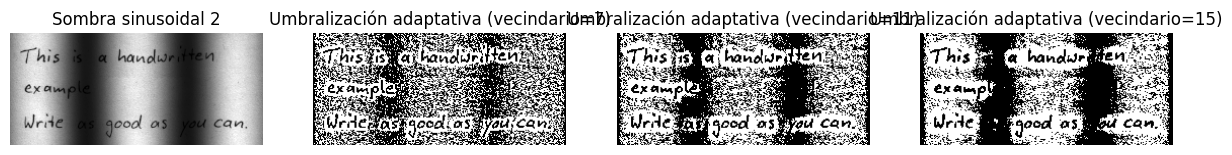

In [62]:
vecindarios = [7, 11, 15]

umbralizaciones = []
for v in vecindarios:
    ti = threshold_local(sinusoidal_image2, block_size=v, method='mean') #NOTA: X debe ser impar
    binary_image = sinusoidal_image2 > ti
    thresholded_image = binary_image*255
    umbralizaciones.append(thresholded_image)


plt.figure(figsize=(15, 6))
plt.subplot(1, 4, 1)
plt.imshow(sinusoidal_image2, cmap='gray')
plt.axis('off')
plt.title('Sombra sinusoidal 2')
for i, v in enumerate(vecindarios):
    plt.subplot(1, 4, i+2)
    plt.imshow(umbralizaciones[i], cmap='gray')
    plt.axis('off')
    plt.title(f'Umbralización adaptativa (vecindario={v})')
plt.show()

El resultado de la umbralización adaptativa difiere del método de Otsu en que este último busca un umbral global para toda la imagen, lo cual, resulta insuficiente ante condiciones de iluminación no uniforme, mientras que, la umbralización adaptativa calcula umbrales locales para cada píxel basándose en las propiedades de su vecindario. Esto permite que el algoritmo se adapte a las variaciones de intensidad, como las sombras introducidas, logrando una segmentación más precisa del texto al enfocarse en el contraste local en lugar de la intensidad absoluta de los píxeles. 

A pesar de los beneficiones mencionados, el resultado de la umbralización adaptativa es altamente sensible al tamaño del vecindario local; un vecindario muy pequeño logra segmentar el texto en zonas de sombra, pero introduce mucho ruido granular en el fondo. Por el contrario, un vecindario muy grande reduce el ruido al promediar más información, pero pierde su capacidad de adaptación local, tendiendo un comportamiento similar al de Otsu y volviendo a incluir las sombras como parte de la segmentación.

Por esta razón, para imágenes con gradientes de luz complejos, no existe un tamaño de vecindario único ideal que pueda funcionar en todos los casos. Es necesario ajustar el tamaño del vecindario para equilibrar la precisión de la segmentación y la cantidad de ruido introducido. Además, es importante tener en cuenta que la umbralización adaptativa puede ser computacionalmente más costosa que el método de Otsu, especialmente para vecindarios grandes.

Para mejorar el resultado y reducir el ruido en ambos casos, se pueden emplear filtros previos para eliminar variaciones de intensidad irrelevantes o, aplicar operaciones posteriores a la segmentación que consigan eliminar ruido, como la eliminación de puntos aislados. Adicionalmente, un análisis a profunidad de los tamaños óptimos del vecindario puede ayudar a econtrar un balance adecuado entre la precisión de la segmentación y la cantidad de ruido introducido.

---

# **2. Segmentación por crecimiento de regiones**

### **2.1 Cree una nueva sección en su notebook**
### **2.2 Cargue la imagen de trabajo y visualícela**

(247, 250)


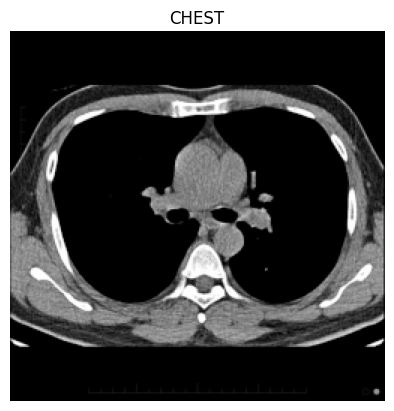

In [63]:
chest_image = cv2.imread(images_path + 'CHEST.png', cv2.IMREAD_GRAYSCALE)
print(chest_image.shape)

plt.imshow(chest_image, cmap='gray')
plt.axis('off')
plt.title('CHEST')
plt.show()

### **2.3 Manualmente, usando paint, cree una máscara asociada al área oscura que correponde a los pulmones, tratando de respetar la región de la manera más precisa posible.**

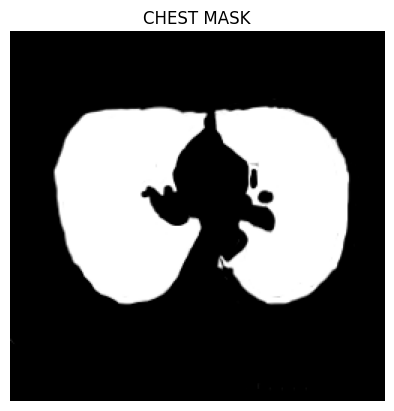

In [64]:
chest_mask_manual = cv2.imread(images_path + 'CHEST_MASK.png', cv2.IMREAD_GRAYSCALE)

plt.imshow(chest_mask_manual, cmap='gray')
plt.axis('off')
plt.title('CHEST MASK')
plt.show()

### **2.4 Usando ahora dos semillas, utilice el algoritmo de crecimiento de regiones para segmentar de forma automática el área de los pulmones. Pruebe con varios valores de tolerancia.**

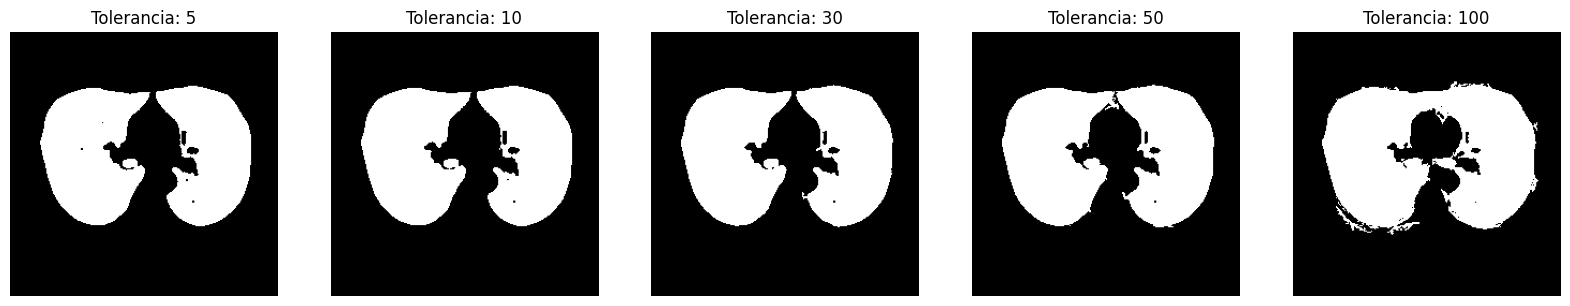

In [65]:
# seleccionar semillas
semilla1 = (70, 70) # region del pulmón izquierdo
semilla2 = (70, 160) # region del pulmón derecho

# variació de intensidad permitida
tolerancias = [5, 10, 30, 50, 100]

results = []
for tol in tolerancias:
    chest_mask_left = flood(chest_image, semilla1, tolerance=tol)
    chest_mask_right = flood(chest_image, semilla2, tolerance=tol)
    chest_mask = chest_mask_left | chest_mask_right
    results.append(chest_mask)

plt.figure(figsize=(20, 4))
for i, tol in enumerate(tolerancias):
    plt.subplot(1, 5, i+1)
    plt.imshow(results[i], cmap='gray')
    plt.axis('off')
    plt.title(f'Tolerancia: {tol}')

Para obtener la segmentación de los pulmones, se seleccionaron manualmente dos semillas correspondientes a cada pulmón. Luego se aplicó el algoritmo de crecimiento de regiones, expandiendose a partir de las semillas seleccionada y utilizando diferentes valores de tolerancia para controlar la expansión.

### **2.5 Compare ambos resultados. ¿Cómo se puede determinar cualitativamente dos regiones? ¿Cuál segmentación tiene mejor calidad?**

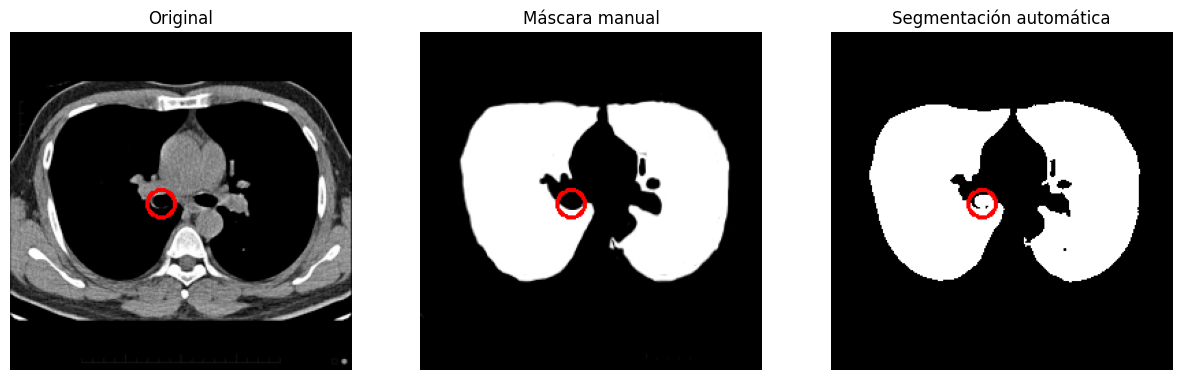

In [66]:
# dibujar un círculo en la posición con error
centro = (110, 125) 
radio = 10  
color = (255, 0, 0) # color rojo
grosor = 2

# leer las imagenes a color
img_1 = cv2.cvtColor(chest_image, cv2.COLOR_GRAY2RGB)
img_2 = cv2.cvtColor(chest_mask_manual, cv2.COLOR_GRAY2RGB)
seg_data = (results[2] * 255).astype('uint8')
img_3 = cv2.cvtColor(seg_data, cv2.COLOR_GRAY2RGB)

# dibujar el círculo rojo
cv2.circle(img_1, centro, radio, color, grosor)
cv2.circle(img_2, centro, radio, color, grosor)
cv2.circle(img_3, centro, radio, color, grosor)

# visualizar
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_1) 
plt.axis('off')
plt.title('Original')

plt.subplot(1, 3, 2)
plt.imshow(img_2)
plt.axis('off')
plt.title('Máscara manual')

plt.subplot(1, 3, 3)
plt.imshow(img_3) 
plt.axis('off')
plt.title('Segmentación automática')

plt.show()

Comparando los resultados de ambas segmentaciones (manual y automática con tolerancia 30 -el mejor resultado de las automáticas-), se observa que la máscara manual presenta una segmentación más completa en cuanto a la anatomía general, pues hay un área de la imagen que el algoritmo de crecimiento de regiones no logró excluir correctamente debido a variaciones en los niveles de gris con ninguno de los niveles de tolerancia. Esta área está delimitada en las imágenes previas con un círculo rojo. Sin embargo, en términos de detalle local, la segmentación automática logra respetar de mejor manera las fronteras sinuosas de los pulmones. Con esto en mente, la segmentación manual tiene una mejor calidad en términos de cobertura general, mientras que, la segmentación automática tiene una mejor calidad en términos de precisión local. Es importante destacar que comparando los resultados en términos de tiempo de segmentación, la automática es mucho más rápida que la manual, lo que puede ser un factor importante a considerar dependiendo del contexto de aplicación.

Para determinar cualitativamente la calidad de las segmentaciones se puede realizar una inspección superponiendo cada máscara sobre la imagen, de manera que se pueda verificar la coincidencia entre las estructuras o, simplemente comparando de forma visual cada máscara con la imagen original en caso de que existan diferencias significativas entre ambas, como lo es este caso particular.


### **2.6 Investigue el coeficiente de Sorensen-Dice. Esta es una medida de la similitud entre dos áreas segmentadas. Aplíquelo sobre las segmentaciones del punto 3 y 4. ¿Cómo puede interpretar el resultado? ¿Respalda el análisis cualitativo el valor obtenido?**

In [67]:
def sorensen_dice_coefficient(mask1, mask2):
    intersection = (mask1 & mask2).sum()
    size_mask1 = mask1.sum()
    size_mask2 = mask2.sum()
    return (2.0 * intersection) / (size_mask1 + size_mask2)

chest_mask_manual_binary = chest_mask_manual > 0 # había tonalidades de gris
for i, result in enumerate(results):
    print(f"Sorensen-Dice coefficient, tolerance {tolerancias[i]}: {sorensen_dice_coefficient(result, chest_mask_manual_binary):.4f}")

Sorensen-Dice coefficient, tolerance 5: 0.9465
Sorensen-Dice coefficient, tolerance 10: 0.9487
Sorensen-Dice coefficient, tolerance 30: 0.9534
Sorensen-Dice coefficient, tolerance 50: 0.9550
Sorensen-Dice coefficient, tolerance 100: 0.9398


El coeficiente de Sorensen-Dice es una métrica que cuantifica la similitud entre dos conjuntos. Se calcula como el doble del tamaño de la intersección de los conjuntos dividido por la suma de sus tamaños. En el contexto de segmentación, un valor de 1 indica una coincidencia perfecta entre las dos segmentaciones, mientras que, un valor de 0 indica que no hay superposición. Para la implementación, se calcula la intersección haciendo una operación lógica AND entre las máscaras binarias de ambas segmentaciones.

Comparando los resultados cualitativos discutidos anteriormente, se nota que entre todas las tolerancias y la segmentación manual hay pequeñas discrepancias en las áreas seleccionadas, probablemente guiada por el área incluida en la máscara manual pero excluida en la máscara automática indicada en el punto 2.5.

Las máscaras más cercanas a la manual son las segmentaciones automáticas con tolerancias de 50 y 30, sin embargo, si se basa el análisis solo considerando el coeficiente Sorensen-Dice, no sería notorio que en la máscara 50 hay una área incluida de más que no corresponde a los pulmones. Por lo tanto, aunque el coeficiente es una herramienta útil para cuantificar la similitud y respalda en su mayoría el análisis cualitativo, es importante no depender exclusicamente de esta métrica.

---

# **3. Segmentación por agrupación**


### **3.1 Cree una nueva sección en su notebook.**
### **3.2 Cargue la imagen de trabajo y visualícela.**

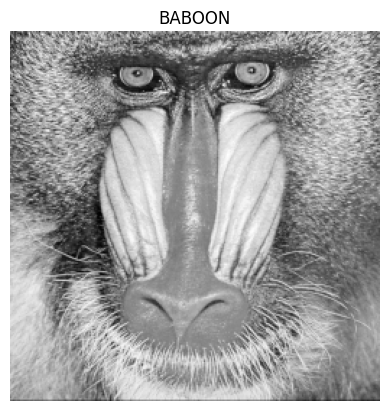

In [68]:
baboon_image = cv2.imread(images_path + 'BABOON.png', cv2.IMREAD_GRAYSCALE)

plt.imshow(baboon_image, cmap='gray')
plt.axis('off')
plt.title('BABOON')
plt.show()


### **3.3 Aplique el algoritmo de K-means para segmentar por agrupación. Utilice un valor de K=3. Visualice los resultados.**


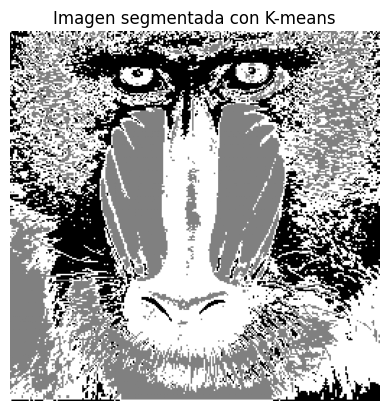

In [69]:
# obtener dimensiones de la imagen
N, M = baboon_image.shape

# definir número de clusters
num_clusters = 3

# aplicar K-means
img_flat = baboon_image.reshape(N*M,1)
model_kmeans = KMeans(n_clusters=num_clusters)
model_kmeans.fit(img_flat)
segmented_image = model_kmeans.labels_.reshape(N,M,1)

# visualizar la imagen segmentada
plt.imshow(segmented_image, cmap='gray')
plt.axis('off')
plt.title('Imagen segmentada con K-means')
plt.show()

### **3.4 Utilice el método del codo para encontrar el valor óptimo de grupos en la imagen. Visualice los resultados ¿Cómo cambia la segmentación?**

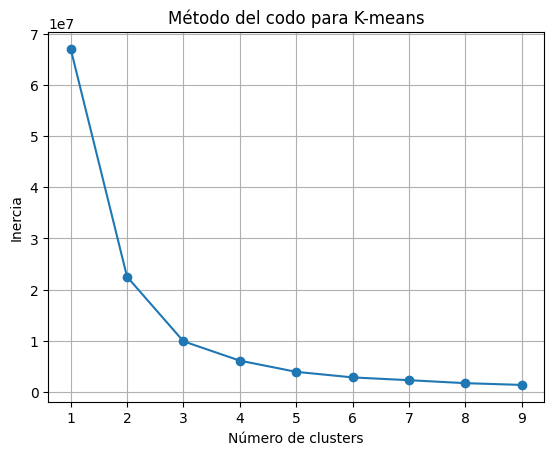

In [70]:
# metodo del codo obteniendo la inercia para diferentes nums de clusters
cluster_range = range(1, 10)

inertia_values = []
for k in cluster_range:
    model = KMeans(n_clusters=k)
    model.fit(img_flat)
    inertia_values.append(model.inertia_)

plt.plot(cluster_range, inertia_values, marker='o')
plt.title('Método del codo para K-means')
plt.xlabel('Número de clusters')
plt.ylabel('Inercia')
plt.xticks(cluster_range)
plt.grid()
plt.show()

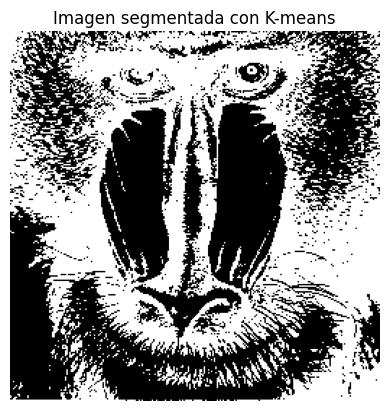

In [71]:
# obtener dimensiones de la imagen
N, M = baboon_image.shape

# definir número de clusters
num_clusters_optimal = 2

# aplicar K-means
img_flat = baboon_image.reshape(N*M,1)
model_kmeans = KMeans(n_clusters=num_clusters_optimal)
model_kmeans.fit(img_flat)
segmented_image = model_kmeans.labels_.reshape(N,M,1)

# visualizar la imagen segmentada
plt.imshow(segmented_image, cmap='gray')
plt.axis('off')
plt.title('Imagen segmentada con K-means')
plt.show()

El método del codo se basa en calcular la suma de las distancias al cuadrado (inercia) entre los puntos y el centroide de su grupo para diferentes valores de K. El valor óptimo de K se identifica como el punto donde la disminución de la inercia comienza a ser menos pronunciada, formando un "codo" en la gráfica. En este caso, el valor óptimo de K está entre 2 y 3. Al comparar ambos valores de K, se observa que con K=2 se logra una segmentación clara entre los rasgos principales del babuino y su pelaje, sin embargo, se llega a perder algo de información relevante en los ojos. Por otro lado, con K=3 se logra una segmentación más detallada y con mayor separación de los rasgos del babuino.


### **3.5 Aplique el algoritmo de súperpixeles SLIC. Utilice un valor de K=25. Visualice los resultados. ¿Cuántos súperpixeles se encontraron?**

Número de súperpixeles: 12


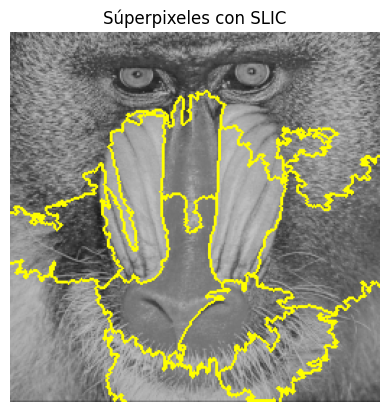

In [72]:
# segments = slic(baboon_image, convert2lab=False, n_segments=25)
segments = slic(baboon_image, n_segments=25, compactness=0.1, convert2lab=False, channel_axis=None)
print(f"Número de súperpixeles: {len(np.unique(segments))}")

#Visualización de los súperpixeles superpuestos en la imagen
plt.imshow(segmentation.mark_boundaries(baboon_image, segments))
plt.axis('off')
plt.title('Súperpixeles con SLIC')
plt.show()


El algoritmo SLIC (Simple Linear Iterative Clustering) segmenta la imagen en superpíxeles agrupando píxeles cercanos que tengan colores o intensidades similares. En este caso, al aplicar SLIC con K=25 se encontraron 12 superpíxeles debido a la fase de post procesamiento del algoritmo, donde se fusionan los superpíxeles pequeños con sus vecinos más cercanos para evitar la generación de superpíxeles demasiado pequeños. 

Como la imagen está en escala de grises, se ajustó la función con convert2lab=False y channel_axis=None para procesar directamente la matriz de intensidades. Además, se bajó el parámetro compactness a 0.1, ya que, el valor por defecto (10.0) genera formas cuadradas, pues tiene más en cuenta la posición de los pixeles que sus intensidades de gris.

### **3.6 Aplique el algoritmo de súperpixeles usando el valor óptimo de grupos calculado en el paso 4. Utilice dicho multiplicado por 4 y por 10. Visualice los resultados ¿Qué puede observar? ¿Qué diferencias hay entre las imágenes generadas?**

Tomamos el valor óptimo como K=3 por las razones mencionadas anteriormente.

Número de súperpixeles (4x): 4
Número de súperpixeles (10x): 14


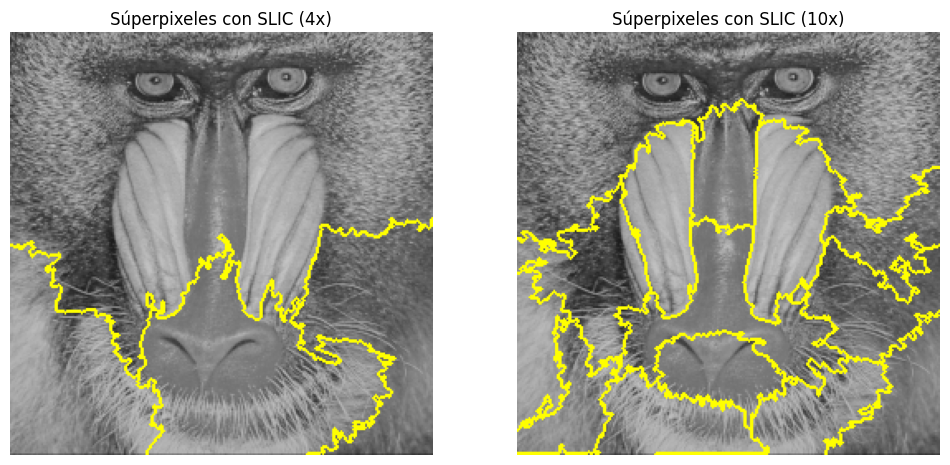

In [73]:
segments_by4 = slic(baboon_image, n_segments=3*4, channel_axis=None, compactness=0.1, convert2lab=False)
segments_by10 = slic(baboon_image, n_segments=3*10, channel_axis=None, compactness=0.1, convert2lab=False)

print(f"Número de súperpixeles (4x): {len(np.unique(segments_by4))}")
print(f"Número de súperpixeles (10x): {len(np.unique(segments_by10))}")

#Visualización de los súperpixeles superpuestos en la imagen
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(segmentation.mark_boundaries(baboon_image, segments_by4))
plt.axis('off')
plt.title('Súperpixeles con SLIC (4x)')

plt.subplot(1, 2, 2)
plt.imshow(segmentation.mark_boundaries(baboon_image, segments_by10))
plt.axis('off')
plt.title('Súperpixeles con SLIC (10x)')
plt.show()


Al comparar los dos multiplicadores, se nota que con el valor de 10x (14 superpíxeles) la imagen se fragmenta mucho más que con el de 4x (4 superpíxeles). Aunque esto permite capturar detalles más pequeños, como los contornos de la nariz o los ojos, también genera una segmentación de regiones que podrían considerarse una sola, como la barba del babuino. Podemos resumir entonces que el multiplicador de 4x genera una segmentación que agrupa áreas muy extensas, mientras que, el de 10x genera una segmentación más detallada pero con una fragmentación excesiva.

### **3.7 ¿Cuál es la diferencia entre las dos técnicas de segmentación por agrupación utilizadas? ¿Cuál presenta el mejor resultado?  ¿Conclusión?**

La diferencia fundamental entre ambos radica en qué información consideran para agrupar los datos. K-means segmenta la imagen basándose exclusivamente en las intensidades de los píxeles (el valor de gris), agrupando elementos que se parecen en tono sin importar en qué parte de la imagen se encuentran. Por el contrario, SLIC no solo mira la intensidad, sino también la posición espacial del píxel. Esto genera superpíxeles, que son regiones compactas y localizadas, a diferencia de los grupos de K-means que pueden estar dispersos por toda la imagen como manchas sueltas.

Al observar los resultados, el algoritmo de K-means logra separar la imagen en grupos más "uniformes" a nivel global. Por ejemplo, con $K=2$, es capaz de aislar el pelaje de los rasgos del babuino, lo que lo hace muy interpretable si se quiere analizar capas de intensidad. Sin embargo, SLIC logra una segmentación que respeta mucho mejor la morfología y las formas del babuino. Un ejemplo de esto está en el pelaje, SLIC puede segmentar la barba como una región distinta al pelaje de los ojos porque entiende que están en lugares diferentes, manteniendo una coherencia visual que K-means pierde al mezclar zonas distantes solo por tener un gris similar.

En conclusión, mientras que K-means es una herramienta útil para simplificar la paleta de colores o intensidades de una imagen, SLIC es superior para tareas donde la "estructura espacial" es clave.

---

# **4. Ejercicio de síntesis**

**Utilizando únicamente las operaciones vistas hasta el momento, segmente la figura de tal manera que los personajes aparezcan sean segmentados correctamente (en blanco), conservando de la mejor manera la figura original, sin introducir artefactos.**

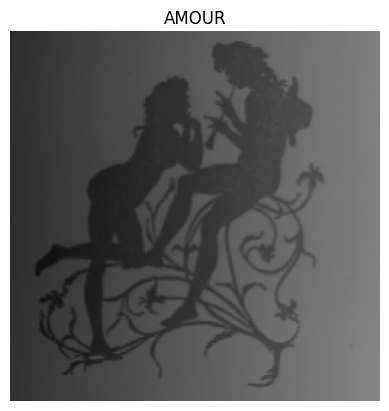

In [209]:
# leer y visualizar la imagen
amour_image = cv2.imread(images_path + 'AMOUR_AVEC_RAMPE.png', cv2.IMREAD_GRAYSCALE)

plt.imshow(amour_image, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.title('AMOUR')
plt.show()

Se van a definir 4 regiones de interés, separadas de manera vertical, cada una con su propia tolerancia y semillas. Luego se aplicará el algoritmo de crecimiento de regiones para cada una y finalmente se ensamblarán las máscaras resultantes para obtener la segmentación completa de los personajes.

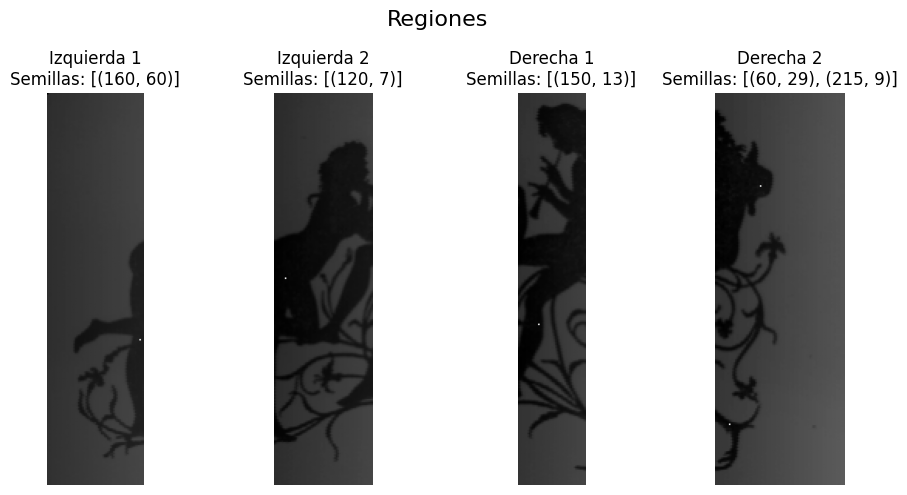

In [212]:
# 1. Definir dimensiones y cortes
N, M = amour_image.shape
c1 = M // 4
c2 = M // 2
c3 = (3 * M) // 4 - 20 # ajuste para conectar regiones

# dividir la imagen en las 4 regiones
regions = {
    'Izquierda 1': amour_image[:, :c1],
    'Izquierda 2': amour_image[:, c1:c2],
    'Derecha 1':   amour_image[:, c2:c3],
    'Derecha 2':   amour_image[:, c3:]
}

# 3. Semillas globales
semillas_globales = {
    'Izquierda 1': [(160, 60)], 
    'Izquierda 2': [(120, 70)], 
    'Derecha 1':   [(150, 140)], 
    'Derecha 2':   [(60, 200), (215, 180)] # esta región tiene dos semillas al tener dos componentes disconexos
}

# visualización de las regiones con las semillas locales como puntos blancos
fig, axes = plt.subplots(1, 4, figsize=(10, 5))
plt.suptitle('Regiones', fontsize=16)

offsets_x = [0, c1, c2, c3]
nombres = list(regions.keys())
semillas_locales = {}

for i, nombre in enumerate(nombres):
    img_vis = regions[nombre].copy()
    semillas_locales[nombre] = []
    
    # iterar sobre las semillas globales de esta región y convertirlas a locales
    for y_g, x_g in semillas_globales[nombre]:
        semilla_local = (y_g, x_g - offsets_x[i]) # se le resta el corte
        
        img_vis[semilla_local] = 255
        semillas_locales[nombre].append(semilla_local)

    # visualizar
    axes[i].imshow(img_vis, cmap='gray')
    axes[i].set_title(f"{nombre}\nSemillas: {semillas_locales[nombre]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

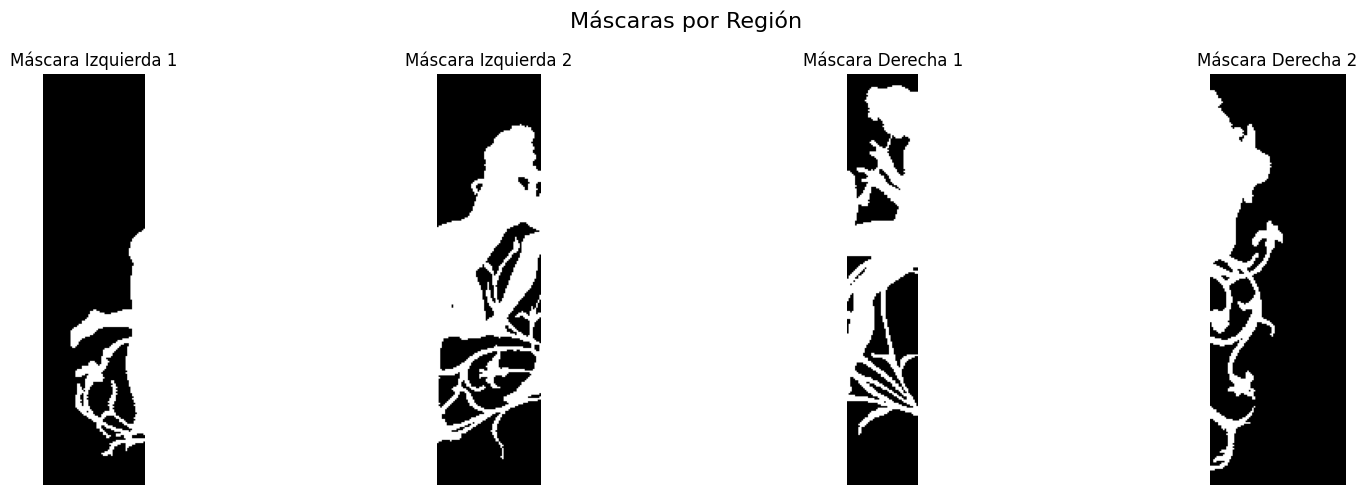

In [213]:
# tolerancias para cada región
tolerancias = {
    'Izquierda 1': 16,
    'Izquierda 2': 28,
    'Derecha 1':   25,
    'Derecha 2':   21
}

# máscara completa para ensamblar las regiones segmentadas
full_mask = np.zeros_like(amour_image, dtype=bool)
mascaras_finales = {}

# crecer las regiones
for nombre in nombres:
    img_region = regions[nombre]
    mask_region = np.zeros(img_region.shape, dtype=bool)
    tol = tolerancias[nombre]
    
    for semilla in semillas_locales[nombre]: # crecer por cada semilla
        m = flood(img_region, semilla, tolerance=tol)
        mask_region |= m  # Unión de máscaras si hay más de una semilla como un OR
    
    # guardar las máscaras 
    mascaras_finales[nombre] = mask_region
    
# unir todas las máscaras
full_mask[:, :c1] = mascaras_finales['Izquierda 1']
full_mask[:, c1:c2] = mascaras_finales['Izquierda 2']
full_mask[:, c2:c3] = mascaras_finales['Derecha 1']
full_mask[:, c3:] = mascaras_finales['Derecha 2']

# visualizar las 4 máscaras por separado (para ajustar tolerancias)
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
plt.suptitle('Máscaras por Región', fontsize=16)

for i, nombre in enumerate(nombres):
    # Mostramos la máscara en blanco (objeto) y negro (fondo)
    axes[i].imshow(mascaras_finales[nombre], cmap='gray')
    axes[i].set_title(f'Máscara {nombre}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

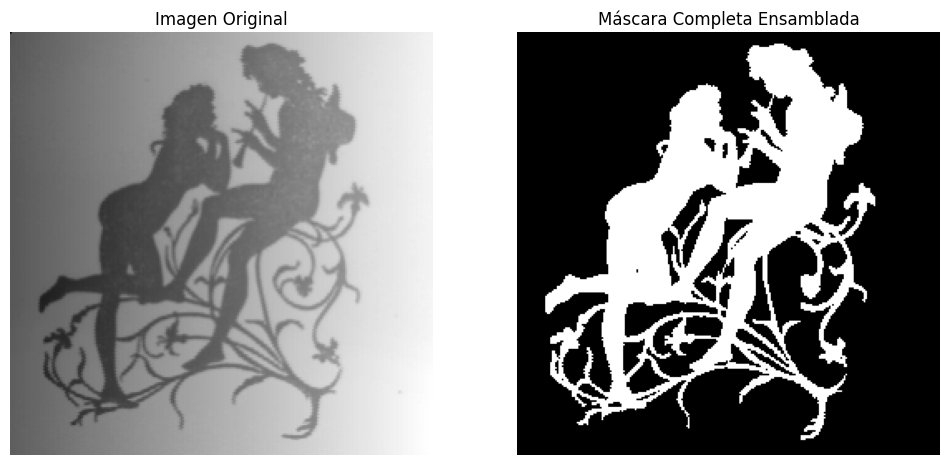

In [214]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(amour_image, cmap='gray')
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(full_mask, cmap='gray')
plt.title('Máscara Completa Ensamblada')
plt.axis('off')
plt.show()

Para optimizar la segmentación, se dividió la imagen en cuatro regiones estratégicas, asignando semillas y tolerancias diferenciadas para cada una. Esta subdivisión se diseñó considerando la distribución de los personajes y el impacto de la rampa de intensidad; al agrupar zonas con propiedades lumínicas similares, pudimos ajustar los parámetros de forma específica. El resultado fue una segmentación que logra separar los personajes y las ramas que los conectan del fondo.

In [77]:
!jupyter nbconvert --to html Taller3.ipynb

[NbConvertApp] Converting notebook Taller3.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 27 image(s).
[NbConvertApp] Writing 4374288 bytes to Taller3.html
